# Supply Chain Shipping Delay Prediction — Linear Regression Stage

This notebook continues the EDA notebook and focuses only on **linear regression methods** for predicting the target:

`shipping_delay_days`

Topics covered:

- Linear Regression baseline
- OLS (Ordinary Least Squares) with `statsmodels`
- Gradient Descent implementation
- Ridge Regression (L2 regularization)
- Lasso Regression (L1 regularization)
- Regularization
- Underfitting and overfitting diagnosis
- Bias and variance interpretation

The notebook deliberately excludes `container_shortage_score` because it contains the same information as `container_availability_index` in reverse form.

## 1. Imports

If `statsmodels` is not installed, run:

```python
pip install statsmodels
```

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 2. Load the processed dataset

The modeling stage starts from the cleaned and feature-engineered dataset produced by the EDA notebook.

In [5]:
def find_processed_file():
    candidates = [
        Path.cwd() / "data" / "processed" / "supply_chain_ml_ready.csv",
        Path.cwd().parent / "data" / "processed" / "supply_chain_ml_ready.csv",
        Path("/mnt/data/data/processed/supply_chain_ml_ready.csv"),
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        "Could not find supply_chain_ml_ready.csv. Run the EDA notebook first."
    )

DATA_PATH = find_processed_file()
print(f"Using dataset: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Dataset shape:", df.shape)
display(df.head())

Using dataset: C:\Users\bunny\Downloads\data\processed\supply_chain_ml_ready.csv
Dataset shape: (31300, 57)


,date,route_id,trade_volume_tonnes,shipping_delay_days,freight_cost_usd,container_availability_index,port_congestion_index,fuel_cost_index,commodity_price_index,weather_disruption_score,geopolitical_risk_score,route_status,carbon_emissions_tonnes,oil_price,natural_gas_price,steel_price,wheat_price,copper_price,commodity_stress_index,origin_country,destination_country,distance_km,shipping_method,trade_route_type,estimated_transit_days,origin_iso3,origin_region,origin_income_group,origin_population,origin_gdp_per_capita,origin_trade_dependency_score,origin_port_capacity_index,origin_logistics_performance_index,destination_iso3,destination_region,destination_income_group,destination_population,destination_gdp_per_capita,destination_trade_dependency_score,destination_port_capacity_index,destination_logistics_performance_index,year,quarter,month,week_of_year,freight_cost_per_tonne,freight_cost_per_km,emissions_per_tonne,emissions_per_km,planned_km_per_day,average_logistics_performance,average_port_capacity,logistics_performance_gap,port_capacity_gap,gdp_per_capita_gap,operational_risk_score,delay_category
0,2015-01-04,R00001,"8,418.6900",7.5500,"4,586.6600",71.4200,82.2200,62.4800,19.2000,59.5100,57.1500,Delayed,"3,681.4900",62.4836,2.5052,500.3132,186.3312,"6,674.4548",19.2000,India,United States,"8,746.0000",Rail,Consumer Goods,19.0000,IND,South Asia,High income,430389014,60735,23.7300,56.0400,86.6600,USA,North America,Low income,250467210,63955,97.9000,21.0600,33.8700,2015,1,1,1,0.5448,0.5244,0.4373,0.4209,460.3158,60.2650,38.5500,52.7900,34.9800,3220,56.3420,High (5-10)
1,2015-01-04,R00023,"20,172.8200",9.5100,"4,967.0400",67.0500,19.3200,62.4800,19.2000,68.1000,65.8900,Delayed,"9,681.9500",62.4836,2.5052,500.3132,186.3312,"6,674.4548",19.2000,United States,Japan,"9,599.0000",Air,Consumer Goods,45.0000,USA,North America,Low income,250467210,63955,97.9000,21.0600,33.8700,JPN,East Asia & Pacific,Upper middle income,435285667,68969,27.2500,65.0600,34.5800,2015,1,1,1,0.2462,0.5175,0.4800,1.0086,213.3111,34.2250,43.0600,0.7100,44.0000,5014,44.7385,High (5-10)
2,2015-01-04,R00022,"4,216.5800",10.7900,"3,345.4100",54.9200,72.5200,62.4800,19.2000,89.9700,90.1500,Delayed,"1,155.5500",62.4836,2.5052,500.3132,186.3312,"6,674.4548",19.2000,United Kingdom,India,"5,481.0000",Sea,Consumer Goods,36.0000,GBR,Europe & Central Asia,Low income,894664919,54707,50.6000,21.2800,54.0100,IND,South Asia,High income,430389014,60735,23.7300,56.0400,86.6600,2015,1,1,1,0.7934,0.6104,0.2740,0.2108,152.2500,70.3350,38.6600,32.6500,34.7600,6028,69.0840,Severe (>10)
3,2015-01-04,R00021,"34,119.2300",2.6700,"3,884.7100",74.0600,44.4100,62.4800,19.2000,39.1200,51.8700,Normal,"12,342.6300",62.4836,2.5052,500.3132,186.3312,"6,674.4548",19.2000,United States,United Kingdom,"7,235.0000",Rail,Manufacturing,3.0000,USA,North America,Low income,250467210,63955,97.9000,21.0600,33.8700,GBR,Europe & Central Asia,Low income,894664919,54707,50.6000,21.2800,54.0100,2015,1,1,1,0.1139,0.5369,0.3617,1.7060,"2,411.6659",43.9400,21.1700,20.1400,0.2200,9248,41.3595,Moderate (2-5)
4,2015-01-04,R00020,"19,754.8100",9.1900,"5,017.8800",55.1300,17.5600,62.4800,19.2000,33.0400,89.7400,Delayed,"9,622.5700",62.4836,2.5052,500.3132,186.3312,"6,674.4548",19.2000,France,Japan,"9,742.0000",Air,Manufacturing,3.0000,FRA,Europe & Central Asia,Low income,649061058,29693,98.6600,38.4700,36.6400,JPN,East Asia & Pacific,Upper middle income,435285667,68969,27.2500,65.0600,34.5800,2015,1,1,1,0.2540,0.5151,0.4871,0.9877,"3,247.3323",35.6100,51.7650,2.0600,26.5900,39276,43.8445,High (5-10)


## 3. Remove redundant and leakage columns

`container_shortage_score` is removed if it still exists in an older saved file because it is mathematically derived from `container_availability_index`.

We also do **not** use:

- `shipping_delay_days` as an input because it is the target.
- `delay_category` because it is derived from the target.
- `route_status` because it may contain post-outcome information.
- raw `date` as a model input; we use the already-created `month` feature instead.
- `operational_risk_score` in these linear models because it is constructed from individual risk variables. Including the composite together with its components would create unnecessary multicollinearity.

In [7]:
TARGET = "shipping_delay_days"

# Remove redundant derived container feature if it exists.
df.drop(columns=["container_shortage_score"], inplace=True, errors="ignore")

print("container_shortage_score present:", "container_shortage_score" in df.columns)
print("Target present:", TARGET in df.columns)

container_shortage_score present: False
Target present: True


## 4. Select model features

The features below were selected from the EDA because they are available before the delay outcome is known and have a reasonable business connection to shipping delay.

We keep the model intentionally interpretable because this stage is focused on linear regression.

In [9]:
numeric_features = [
    "trade_volume_tonnes",
    "freight_cost_per_tonne",
    "container_availability_index",
    "port_congestion_index",
    "fuel_cost_index",
    "commodity_stress_index",
    "weather_disruption_score",
    "geopolitical_risk_score",
    "distance_km",
    "estimated_transit_days",
    "month",
]

categorical_features = [
    "shipping_method",
    "trade_route_type",
]

model_features = numeric_features + categorical_features

X = df[model_features].copy()
y = df[TARGET].copy()

print("Number of input features before encoding:", len(model_features))
print("Target:", TARGET)
display(X.head())

Number of input features before encoding: 13
Target: shipping_delay_days


,trade_volume_tonnes,freight_cost_per_tonne,container_availability_index,port_congestion_index,fuel_cost_index,commodity_stress_index,weather_disruption_score,geopolitical_risk_score,distance_km,estimated_transit_days,month,shipping_method,trade_route_type
0,"8,418.6900",0.5448,71.4200,82.2200,62.4800,19.2000,59.5100,57.1500,"8,746.0000",19.0000,1,Rail,Consumer Goods
1,"20,172.8200",0.2462,67.0500,19.3200,62.4800,19.2000,68.1000,65.8900,"9,599.0000",45.0000,1,Air,Consumer Goods
2,"4,216.5800",0.7934,54.9200,72.5200,62.4800,19.2000,89.9700,90.1500,"5,481.0000",36.0000,1,Sea,Consumer Goods
3,"34,119.2300",0.1139,74.0600,44.4100,62.4800,19.2000,39.1200,51.8700,"7,235.0000",3.0000,1,Rail,Manufacturing
4,"19,754.8100",0.2540,55.1300,17.5600,62.4800,19.2000,33.0400,89.7400,"9,742.0000",3.0000,1,Air,Manufacturing


## 5. Time-aware train/test split

Because the goal is to predict future shipping delays, we avoid randomly mixing future records into the training set.

- First 80% of dates → training data
- Last 20% of dates → test data

This gives a more realistic measure of future model performance.

In [11]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

train_dates = df["date"].iloc[:split_index]
test_dates = df["date"].iloc[split_index:]

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows : {len(X_test):,}")
print(f"Train period : {train_dates.min().date()} to {train_dates.max().date()}")
print(f"Test period  : {test_dates.min().date()} to {test_dates.max().date()}")

Training rows: 25,040
Testing rows : 6,260
Train period : 2015-01-04 to 2024-08-04
Test period  : 2024-08-04 to 2026-12-27


## 6. Preprocessing

Linear models work best when numeric features are on comparable scales.

- Numeric columns → `StandardScaler`
- Categorical columns → One-hot encoding
- `drop="first"` avoids the dummy-variable trap for each categorical feature.

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features,
        ),
    ],
    verbose_feature_names_out=False,
)

## 7. Evaluation function

We use three regression metrics:

- **MAE** — average absolute error in days.
- **RMSE** — penalizes larger prediction errors more strongly.
- **R²** — proportion of target variation explained by the model.

A good model should have low MAE/RMSE and a higher R² on unseen test data.

In [15]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_metrics = regression_metrics(y_train, train_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    result = {
        "Model": name,
        "Train_MAE": train_metrics["MAE"],
        "Test_MAE": test_metrics["MAE"],
        "Train_RMSE": train_metrics["RMSE"],
        "Test_RMSE": test_metrics["RMSE"],
        "Train_R2": train_metrics["R2"],
        "Test_R2": test_metrics["R2"],
        "R2_Gap": train_metrics["R2"] - test_metrics["R2"],
    }

    return result, train_pred, test_pred

## 8. Simple baseline

Before fitting regression models, we compare them with a very simple baseline: always predict the training-set average delay.

A useful model should outperform this baseline.

In [17]:
baseline_prediction = np.repeat(y_train.mean(), len(y_test))
baseline_metrics = regression_metrics(y_test, baseline_prediction)

print("Baseline prediction (days):", round(y_train.mean(), 3))
print(baseline_metrics)

Baseline prediction (days): 6.276
{'MAE': 2.609419670890792, 'RMSE': 3.282422018118488, 'R2': -0.026267159062789203}


# 9. Linear Regression

Linear regression models the target as a weighted combination of the input features.

The coefficients are estimated by minimizing the sum of squared residuals.

In [19]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ]
)

linear_model.fit(X_train, y_train)

linear_result, linear_train_pred, linear_test_pred = evaluate_model(
    "Linear Regression (OLS)",
    linear_model,
    X_train,
    y_train,
    X_test,
    y_test,
)

display(pd.DataFrame([linear_result]))

,Model,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_R2,Test_R2,R2_Gap
0,Linear Regression (OLS),1.5905,6.7620,1.9886,11.9161,0.5234,-12.5251,13.0485


## 9.1 Actual vs predicted values

Points closer to the diagonal represent more accurate predictions.

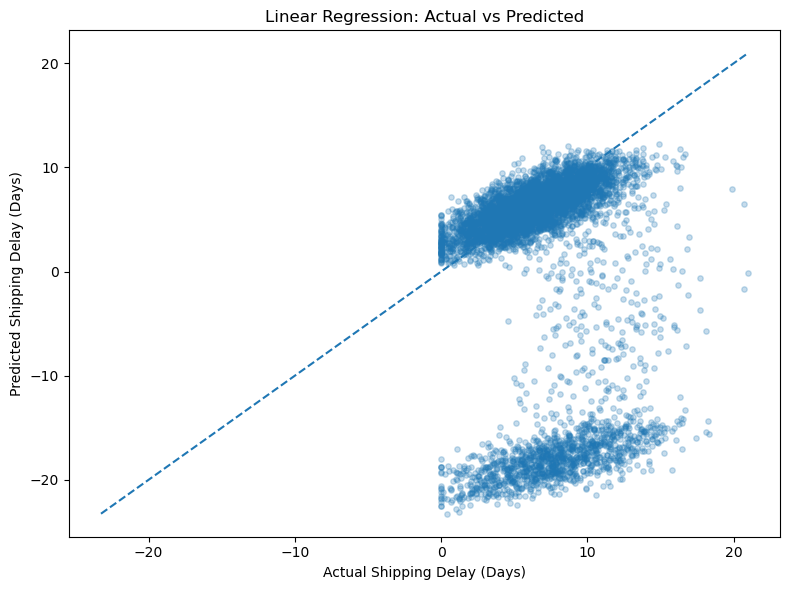

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, linear_test_pred, alpha=0.25, s=15)

low = min(y_test.min(), linear_test_pred.min())
high = max(y_test.max(), linear_test_pred.max())
plt.plot([low, high], [low, high], linestyle="--")

plt.xlabel("Actual Shipping Delay (Days)")
plt.ylabel("Predicted Shipping Delay (Days)")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()

# 10. OLS Method with Statsmodels

`sklearn.LinearRegression` and `statsmodels.OLS` both estimate ordinary least squares coefficients. `statsmodels` additionally provides statistical diagnostics such as:

- coefficient estimates
- standard errors
- t-statistics
- p-values
- confidence intervals
- condition number

The condition number is useful for identifying multicollinearity or numerical instability.

In [23]:
# Fit the preprocessing only on training data.
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

processed_feature_names = preprocessor.get_feature_names_out()

X_train_ols = pd.DataFrame(
    X_train_processed,
    columns=processed_feature_names,
    index=X_train.index,
)
X_test_ols = pd.DataFrame(
    X_test_processed,
    columns=processed_feature_names,
    index=X_test.index,
)

X_train_ols_const = sm.add_constant(X_train_ols, has_constant="add")
X_test_ols_const = sm.add_constant(X_test_ols, has_constant="add")

ols_model = sm.OLS(y_train, X_train_ols_const).fit()

print(ols_model.summary())

                             OLS Regression Results                            
Dep. Variable:     shipping_delay_days   R-squared:                       0.523
Model:                             OLS   Adj. R-squared:                  0.523
Method:                  Least Squares   F-statistic:                     1527.
Date:                 Fri, 07 Aug 2026   Prob (F-statistic):               0.00
Time:                         01:14:52   Log-Likelihood:                -52744.
No. Observations:                25040   AIC:                         1.055e+05
Df Residuals:                    25021   BIC:                         1.057e+05
Df Model:                           18                                         
Covariance Type:             nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------


## 10.1 OLS coefficients and significance

Large coefficient magnitudes together with a high condition number can indicate unstable coefficients caused by multicollinearity.

In [25]:
ols_coefficients = pd.DataFrame(
    {
        "coefficient": ols_model.params,
        "p_value": ols_model.pvalues,
    }
).sort_values("coefficient", key=lambda s: s.abs(), ascending=False)

print("OLS condition number:", round(ols_model.condition_number, 2))
display(ols_coefficients.head(20))

OLS condition number: 9173.74


,coefficient,p_value
container_availability_index,-28.9414,0.5734
geopolitical_risk_score,-27.5108,0.5925
const,6.3096,0.0000
port_congestion_index,1.1385,0.0000
weather_disruption_score,1.0061,0.0000
trade_route_type_Energy,-0.0693,0.1367
shipping_method_Rail,-0.0529,0.1843
trade_route_type_Consumer Goods,0.0480,0.2486
freight_cost_per_tonne,0.0479,0.0212
shipping_method_Road,-0.0290,0.5350


# 11. Linear Regression with Gradient Descent

Ordinary Least Squares can also be optimized iteratively using gradient descent.

At each iteration, the coefficients move in the direction that reduces Mean Squared Error.

The code below applies **batch gradient descent from scratch** to the same preprocessed training matrix.

In [27]:
def fit_gradient_descent(X, y, learning_rate=0.03, iterations=1000):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    # Add a column of ones for the intercept.
    X_bias = np.c_[np.ones(len(X)), X]

    weights = np.zeros(X_bias.shape[1])
    losses = []

    for iteration in range(iterations):
        predictions = X_bias @ weights
        errors = predictions - y

        mse = np.mean(errors ** 2)
        losses.append(mse)

        gradient = (2 / len(X_bias)) * (X_bias.T @ errors)
        weights -= learning_rate * gradient

    return weights, losses


def gradient_descent_predict(X, weights):
    X = np.asarray(X, dtype=float)
    X_bias = np.c_[np.ones(len(X)), X]
    return X_bias @ weights


gd_weights, gd_losses = fit_gradient_descent(
    X_train_processed,
    y_train,
    learning_rate=0.03,
    iterations=1000,
)

gd_train_pred = gradient_descent_predict(X_train_processed, gd_weights)
gd_test_pred = gradient_descent_predict(X_test_processed, gd_weights)

gd_train_metrics = regression_metrics(y_train, gd_train_pred)
gd_test_metrics = regression_metrics(y_test, gd_test_pred)

gd_result = {
    "Model": "Linear Regression - Gradient Descent",
    "Train_MAE": gd_train_metrics["MAE"],
    "Test_MAE": gd_test_metrics["MAE"],
    "Train_RMSE": gd_train_metrics["RMSE"],
    "Test_RMSE": gd_test_metrics["RMSE"],
    "Train_R2": gd_train_metrics["R2"],
    "Test_R2": gd_test_metrics["R2"],
    "R2_Gap": gd_train_metrics["R2"] - gd_test_metrics["R2"],
}

display(pd.DataFrame([gd_result]))

,Model,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_R2,Test_R2,R2_Gap
0,Linear Regression - Gradient Descent,1.5916,1.8038,1.9896,2.3182,0.5230,0.4881,0.0348


## 11.1 Gradient descent convergence

The loss should decrease and then stabilize. This shows that gradient descent is learning coefficients that reduce prediction error.

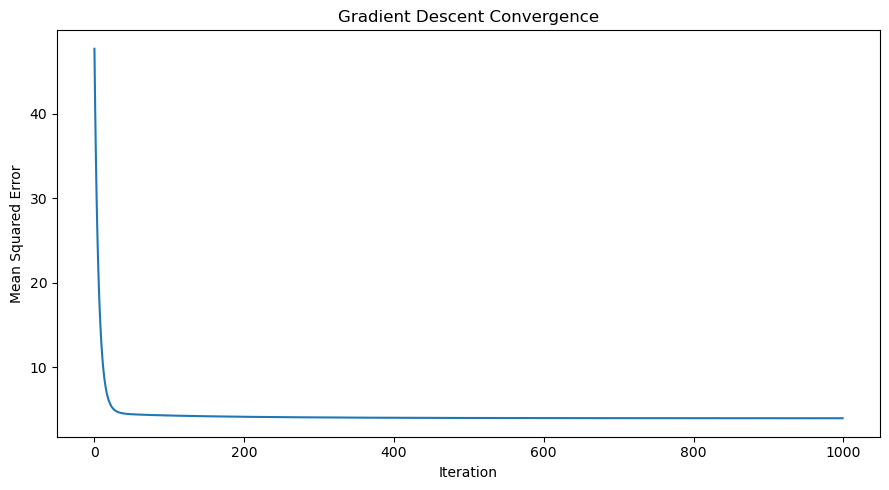

Initial MSE: 47.686
Final MSE  : 3.9586


In [29]:
plt.figure(figsize=(9, 5))
plt.plot(gd_losses)
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.title("Gradient Descent Convergence")
plt.tight_layout()
plt.show()

print("Initial MSE:", round(gd_losses[0], 4))
print("Final MSE  :", round(gd_losses[-1], 4))

# 12. Regularization

Regularization reduces coefficient instability and helps control overfitting.

### Ridge Regression — L2 regularization

Ridge penalizes large squared coefficients. It usually keeps all features but shrinks unstable coefficients toward zero.

### Lasso Regression — L1 regularization

Lasso penalizes absolute coefficient size. It can shrink some coefficients exactly to zero and therefore perform feature selection.

We tune the regularization strength (`alpha`) using **TimeSeriesSplit** on the training period only.

In [31]:
time_cv = TimeSeriesSplit(n_splits=5)

ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge()),
    ]
)

ridge_search = GridSearchCV(
    ridge_pipeline,
    param_grid={"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=time_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

ridge_search.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_search.best_params_["model__alpha"])
print("Best CV RMSE:", round(-ridge_search.best_score_, 4))

ridge_model = ridge_search.best_estimator_
ridge_result, ridge_train_pred, ridge_test_pred = evaluate_model(
    "Ridge Regression",
    ridge_model,
    X_train,
    y_train,
    X_test,
    y_test,
)

display(pd.DataFrame([ridge_result]))

Best Ridge alpha: 10.0
Best CV RMSE: 1.9863


,Model,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_R2,Test_R2,R2_Gap
0,Ridge Regression,1.5905,1.8025,1.9886,2.3161,0.5234,0.4890,0.0344


In [32]:
lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(max_iter=20000)),
    ]
)

lasso_search = GridSearchCV(
    lasso_pipeline,
    param_grid={"model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]},
    cv=time_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

lasso_search.fit(X_train, y_train)

print("Best Lasso alpha:", lasso_search.best_params_["model__alpha"])
print("Best CV RMSE:", round(-lasso_search.best_score_, 4))

lasso_model = lasso_search.best_estimator_
lasso_result, lasso_train_pred, lasso_test_pred = evaluate_model(
    "Lasso Regression",
    lasso_model,
    X_train,
    y_train,
    X_test,
    y_test,
)

display(pd.DataFrame([lasso_result]))

Best Lasso alpha: 0.01
Best CV RMSE: 1.986


,Model,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_R2,Test_R2,R2_Gap
0,Lasso Regression,1.5910,1.8683,1.9891,2.4191,0.5232,0.4426,0.0806


## 12.1 Compare coefficient shrinkage

This shows how Ridge and Lasso regularization change coefficient magnitude relative to ordinary linear regression.

In [34]:
# All three pipelines use the same preprocessing structure.
feature_names = ridge_model.named_steps["preprocessor"].get_feature_names_out()

linear_coefficients = linear_model.named_steps["model"].coef_
ridge_coefficients = ridge_model.named_steps["model"].coef_
lasso_coefficients = lasso_model.named_steps["model"].coef_

coefficient_comparison = pd.DataFrame(
    {
        "feature": feature_names,
        "linear": linear_coefficients,
        "ridge": ridge_coefficients,
        "lasso": lasso_coefficients,
    }
)

coefficient_comparison["linear_abs"] = coefficient_comparison["linear"].abs()
coefficient_comparison = coefficient_comparison.sort_values(
    "linear_abs", ascending=False
)

display(coefficient_comparison.drop(columns="linear_abs").head(20))

print(
    "Lasso coefficients exactly equal to zero:",
    int((lasso_coefficients == 0).sum()),
    "out of",
    len(lasso_coefficients),
)

,feature,linear,ridge,lasso
2,container_availability_index,-28.9414,-0.7173,-1.4133
7,geopolitical_risk_score,-27.5108,0.7130,0.0096
3,port_congestion_index,1.1385,1.1381,1.1285
6,weather_disruption_score,1.0061,1.0057,0.9961
15,trade_route_type_Energy,-0.0693,-0.0693,-0.0224
11,shipping_method_Rail,-0.0529,-0.0527,-0.0000
14,trade_route_type_Consumer Goods,0.0480,0.0479,0.0183
1,freight_cost_per_tonne,0.0479,0.0478,0.0226
12,shipping_method_Road,-0.0290,-0.0288,-0.0000
16,trade_route_type_Manufacturing,0.0287,0.0286,0.0000


Lasso coefficients exactly equal to zero: 10 out of 18


# 13. Underfitting Demonstration

An underfit model is too simple to capture the important structure in the data.

To demonstrate this on the real dataset, we train a model using only `weather_disruption_score` even though the EDA showed that shipping delay depends on several operational risks.

If both train and test R² are low, that is a practical sign of **high bias / underfitting**.

In [36]:
underfit_feature = ["weather_disruption_score"]

underfit_model = Pipeline(
    steps=[
        ("scale", StandardScaler()),
        ("model", LinearRegression()),
    ]
)

underfit_model.fit(X_train[underfit_feature], y_train)

underfit_train_pred = underfit_model.predict(X_train[underfit_feature])
underfit_test_pred = underfit_model.predict(X_test[underfit_feature])

underfit_train_metrics = regression_metrics(y_train, underfit_train_pred)
underfit_test_metrics = regression_metrics(y_test, underfit_test_pred)

underfit_result = {
    "Model": "Underfit Demo - Weather Only",
    "Train_MAE": underfit_train_metrics["MAE"],
    "Test_MAE": underfit_test_metrics["MAE"],
    "Train_RMSE": underfit_train_metrics["RMSE"],
    "Test_RMSE": underfit_test_metrics["RMSE"],
    "Train_R2": underfit_train_metrics["R2"],
    "Test_R2": underfit_test_metrics["R2"],
    "R2_Gap": underfit_train_metrics["R2"] - underfit_test_metrics["R2"],
}

display(pd.DataFrame([underfit_result]))

,Model,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_R2,Test_R2,R2_Gap
0,Underfit Demo - Weather Only,2.1731,2.4657,2.6986,3.1121,0.1224,0.0775,0.0449


# 14. Overfitting / High-Variance Diagnosis

A model is concerning when it performs much better on training data than on future test data.

For this dataset, ordinary unregularized OLS can become unstable because several risk variables are strongly related to each other. A large train-test gap or negative test R² indicates poor generalization.

Ridge is expected to reduce this instability by shrinking coefficients.

In [38]:
all_results = pd.DataFrame(
    [
        underfit_result,
        linear_result,
        gd_result,
        ridge_result,
        lasso_result,
    ]
)

all_results = all_results.sort_values("Test_RMSE")
display(all_results)

,Model,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_R2,Test_R2,R2_Gap
3,Ridge Regression,1.5905,1.8025,1.9886,2.3161,0.5234,0.4890,0.0344
2,Linear Regression - Gradient Descent,1.5916,1.8038,1.9896,2.3182,0.5230,0.4881,0.0348
4,Lasso Regression,1.5910,1.8683,1.9891,2.4191,0.5232,0.4426,0.0806
0,Underfit Demo - Weather Only,2.1731,2.4657,2.6986,3.1121,0.1224,0.0775,0.0449
1,Linear Regression (OLS),1.5905,6.7620,1.9886,11.9161,0.5234,-12.5251,13.0485


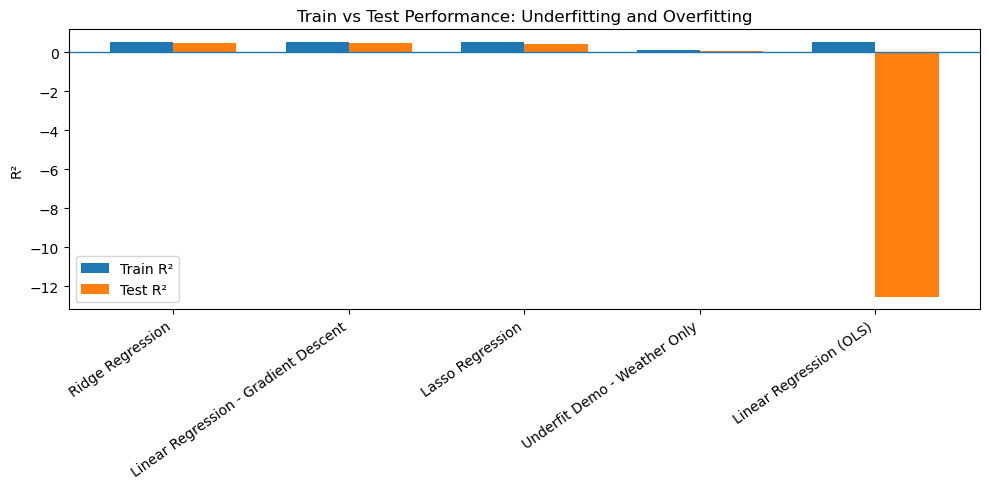

In [39]:
plt.figure(figsize=(10, 5))
positions = np.arange(len(all_results))
width = 0.36

plt.bar(
    positions - width / 2,
    all_results["Train_R2"],
    width,
    label="Train R²",
)
plt.bar(
    positions + width / 2,
    all_results["Test_R2"],
    width,
    label="Test R²",
)

plt.axhline(0, linewidth=1)
plt.xticks(positions, all_results["Model"], rotation=35, ha="right")
plt.ylabel("R²")
plt.title("Train vs Test Performance: Underfitting and Overfitting")
plt.legend()
plt.tight_layout()
plt.show()

# 15. Bias and Variance Interpretation

Bias and variance are concepts rather than two columns directly produced by a regression model.

### High bias

A model is too simple and misses real patterns.

Typical sign:

- low training performance
- low testing performance

The weather-only model is used as the **underfitting/high-bias example**.

### High variance

A model is too sensitive to the training data or unstable coefficients.

Typical sign:

- noticeably better training performance than test performance
- large train-test gap
- unstable coefficients

The unregularized OLS model can show this behavior in this dataset because correlated predictors make its coefficients unstable.

### Balanced model

A useful model has:

- reasonable training performance
- similar test performance
- a small generalization gap

Ridge regularization is specifically designed to reduce variance by shrinking coefficient magnitude.

In [41]:
bias_variance_diagnosis = all_results[
    ["Model", "Train_R2", "Test_R2", "R2_Gap", "Test_RMSE"]
].copy()


def diagnose(row):
    if row["Train_R2"] < 0.25 and row["Test_R2"] < 0.25:
        return "Likely underfitting / high bias"
    if row["Test_R2"] < 0 or row["R2_Gap"] > 0.20:
        return "Likely high variance / poor generalization"
    if row["R2_Gap"] < 0.10 and row["Test_R2"] > 0.35:
        return "Reasonably balanced"
    return "Review model behavior"


bias_variance_diagnosis["Diagnosis"] = bias_variance_diagnosis.apply(
    diagnose, axis=1
)

display(bias_variance_diagnosis)

,Model,Train_R2,Test_R2,R2_Gap,Test_RMSE,Diagnosis
3,Ridge Regression,0.5234,0.4890,0.0344,2.3161,Reasonably balanced
2,Linear Regression - Gradient Descent,0.5230,0.4881,0.0348,2.3182,Reasonably balanced
4,Lasso Regression,0.5232,0.4426,0.0806,2.4191,Reasonably balanced
0,Underfit Demo - Weather Only,0.1224,0.0775,0.0449,3.1121,Likely underfitting / high bias
1,Linear Regression (OLS),0.5234,-12.5251,13.0485,11.9161,Likely high variance / poor generalization


# 16. Final Model Comparison

Use test-set performance to select the strongest linear model. Do not select a model using training R² alone.

In [43]:
comparison = all_results[
    [
        "Model",
        "Train_MAE",
        "Test_MAE",
        "Train_RMSE",
        "Test_RMSE",
        "Train_R2",
        "Test_R2",
        "R2_Gap",
    ]
].sort_values("Test_RMSE")

display(comparison)

best_model_name = comparison.iloc[0]["Model"]
print("Best linear-family model by Test RMSE:", best_model_name)

,Model,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_R2,Test_R2,R2_Gap
3,Ridge Regression,1.5905,1.8025,1.9886,2.3161,0.5234,0.4890,0.0344
2,Linear Regression - Gradient Descent,1.5916,1.8038,1.9896,2.3182,0.5230,0.4881,0.0348
4,Lasso Regression,1.5910,1.8683,1.9891,2.4191,0.5232,0.4426,0.0806
0,Underfit Demo - Weather Only,2.1731,2.4657,2.6986,3.1121,0.1224,0.0775,0.0449
1,Linear Regression (OLS),1.5905,6.7620,1.9886,11.9161,0.5234,-12.5251,13.0485


Best linear-family model by Test RMSE: Ridge Regression


## 17. Business Interpretation

The purpose of this modeling stage is to estimate **how many days a future trade-route operation may be delayed**.

From the EDA, the strongest delay signals came from operational and environmental risk variables such as container availability, port congestion, weather disruption, and geopolitical risk.

This notebook shows an additional modeling lesson:

- A simple model using only one risk factor can **underfit** because shipping delays are caused by multiple factors.
- Ordinary OLS can become unstable when predictors are highly correlated.
- **Ridge regularization** can stabilize coefficients and improve future generalization.
- **Lasso regularization** can reduce model complexity and remove weak predictors by shrinking some coefficients to zero.
- Gradient descent provides another optimization approach for learning linear regression coefficients.

The final choice should be based primarily on unseen test MAE, RMSE, R², and the train-test generalization gap.

## 18. Next Stage

After completing this linear-regression comparison, the next modeling stage can compare these results with non-linear algorithms such as Random Forest and XGBoost. Those models may capture interactions and non-linear relationships that a linear model cannot represent.